# 2D Free energy plot

This notebook shows a way to plot 2D free energy plot using the free energy computed from dbfold package. Outpute of dbfold fes analysis should be saved as pickle file to be compatible with the methods below. Otherwise, please modify the code to

In [6]:
import dbfold
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
data_dict = pickle.load(open('/n/home01/kibumpark/group_folder/p19__Actin/Analysis/rmsd_fes/ACTA_cryo_rmsd_fes.pickle','rb'))

In [8]:
results = data_dict['results']
bin_centers = data_dict['bin_centers']

In [18]:
X = bin_centers[:, 0].reshape(200, 100)
Y = bin_centers[:, 1].reshape(200, 100)

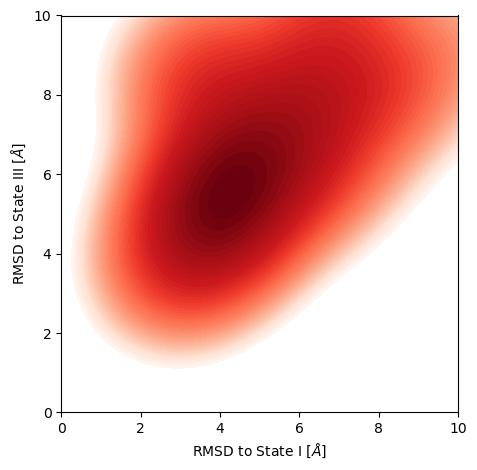

In [26]:
indices = (0,2)
label_dict = {0: 'State I', 1: 'State II', 2: 'State III', 3: 'State IV', 4: 'Native'}
levels = np.linspace(0, 5, 50)
plt.contourf(X, Y, results['f_i'].reshape(X.shape), levels=levels, cmap=plt.cm.Reds_r)
plt.axis('square')
plt.ylim(0,10)
plt.xlim(0,10)
plt.xlabel(f'RMSD to {label_dict[indices[0]]} [$\AA$]')
plt.ylabel(f'RMSD to {label_dict[indices[1]]} [$\AA$]')
plt.tight_layout()

In [29]:
f_i = results['f_i'].reshape(X.shape)
min_idx = np.unravel_index(np.argmin(f_i), f_i.shape)
x_min = X[min_idx]
y_min = Y[min_idx]
f_min = f_i[min_idx]
print(f"Analysing ACTA_cryo - X:{label_dict[indices[0]].replace(' ','_')} - Y:{label_dict[indices[1]].replace(' ','_')}\n")
print(f"Minimum F = {f_min:.4f} at X = {x_min:.4f}, Y = {y_min:.4f}\n")

Analysing ACTA_cryo - X:State_I - Y:State_III

Minimum F = 0.0000 at X = 4.2424, Y = 5.5276



In [ ]:

label_dict = {0: 'State I', 1: 'State II', 2: 'State III', 3: 'State IV', 4: 'Native'}

f_i_scipy = f_i_scipy.reshape(X.shape)
levels = np.linspace(0, 5, 50)
plt.contourf(X, Y, f_i_scipy, levels=levels, cmap=plt.cm.Reds_r)
plt.axis('square')
plt.xlabel(f'RMSD to {label_dict[indices[0]]} [$\AA$]')
plt.ylabel(f'RMSD to {label_dict[indices[1]]} [$\AA$]')
plt.tight_layout()


print(f"Minimum F = {f_min:.4f} at X = {x_min:.4f}, Y = {y_min:.4f}")

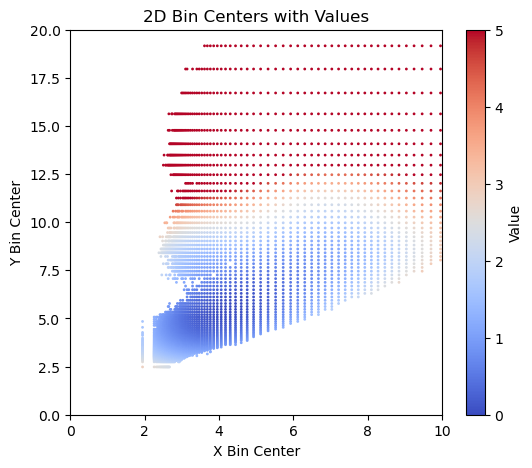

In [4]:
df = pd.DataFrame({
    'x': bin_centers[:, 0],
    'y': bin_centers[:, 1],
    'value': results['f_i']
})

# Use matplotlib for colorbar
plt.figure(figsize=(6, 5))
sc = plt.scatter(df['x'], df['y'], c=df['value'], cmap='coolwarm', vmax=5,s=1)
plt.colorbar(sc, label='Value')
plt.xlabel('X Bin Center')
plt.ylabel('Y Bin Center')
plt.xlim(0,10)
plt.ylim(0,20)
plt.title('2D Bin Centers with Values')
plt.show()

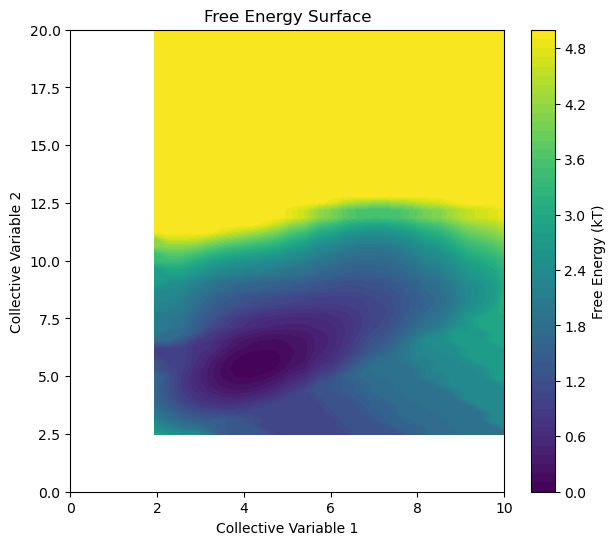

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Assuming:
# bin_centers.shape == (N, 2)
# F.shape == (N,) = free energy

x = bin_centers[:, 0]
y = bin_centers[:, 1]
z = np.clip(results['f_i'], a_min=None, a_max=5)

# Create a regular grid over the domain
xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
grid_x, grid_y = np.meshgrid(xi, yi)

# Interpolate free energy onto the grid
grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')  # 'linear' or 'nearest' are options too

# Plot as heatmap
plt.figure(figsize=(7, 6))
plt.contourf(grid_x, grid_y, grid_z, levels=50, cmap='viridis')
cbar = plt.colorbar(label='Free Energy (kT)')
plt.xlim(0,10)
plt.ylim(0,20)
plt.xlabel('Collective Variable 1')
plt.ylabel('Collective Variable 2')
plt.title('Free Energy Surface')
plt.show()